In [79]:
include("CRD_STA.jl")
using Plots
using Arpack
using SparseArrays
using NonlinearEigenproblems

In [102]:
N_cheb = 49
Mr = 0.1
gamma = 1.4
sigma = 0.72
Ro = 1
Co = 0
Tw = 1
Ma = Mr/R
u0,v0,w0,f,q,D,D2,x = baseflow_var(N_cheb,Ro,Co)
H,T = T_ca(Mr,f,q,w0,gamma,Tw)
F,G,H,T,rho,z = interp(u0,v0,H,T,x,N_cheb,"sim")
lam = - (2/3) * T
kappa = (1/sigma) * T

┌ Warning: Instability detected. Aborting
└ @ SciMLBase /home/a5703/.julia/packages/SciMLBase/rvXrA/src/integrator_interface.jl:631
┌ Warning: Instability detected. Aborting
└ @ SciMLBase /home/a5703/.julia/packages/SciMLBase/rvXrA/src/integrator_interface.jl:631
┌ Warning: Instability detected. Aborting
└ @ SciMLBase /home/a5703/.julia/packages/SciMLBase/rvXrA/src/integrator_interface.jl:631
┌ Warning: Instability detected. Aborting
└ @ SciMLBase /home/a5703/.julia/packages/SciMLBase/rvXrA/src/integrator_interface.jl:631
┌ Warning: Instability detected. Aborting
└ @ SciMLBase /home/a5703/.julia/packages/SciMLBase/rvXrA/src/integrator_interface.jl:631
┌ Warning: Instability detected. Aborting
└ @ SciMLBase /home/a5703/.julia/packages/SciMLBase/rvXrA/src/integrator_interface.jl:631
┌ Warning: Instability detected. Aborting
└ @ SciMLBase /home/a5703/.julia/packages/SciMLBase/rvXrA/src/integrator_interface.jl:631
┌ Warning: Instability detected. Aborting
└ @ SciMLBase /home/a5703/.julia/p

50×1 Matrix{Float64}:
 1.3888888888888888
 1.388895580334972
 1.3889155211447755
 1.3889483078904705
 1.3889932593288896
 1.3890494052716762
 1.3891154754065
 1.3891898925716826
 1.3892707762343885
 1.3893559628266612
 ⋮
 1.3888908459046652
 1.3888891260542324
 1.3888890154480353
 1.3888890140605339
 1.3888890140681194
 1.3888890140379715
 1.3888890140379715
 1.3888890140379715
 1.3888890140379715

In [203]:
al = 0.484
R0 = 27.4
be = 0.115
B0,B1 = Timemode(F,G,H,rho,lam,kappa,T,sigma,gamma,R0,Ma,al,be,N_cheb,Ro,Co)
c = eigen(B0,B1)
eigval = c.values
eigvec = c.vectors
val = filter(x->abs(imag(x))<0.005&&abs(real(x))<0.001,eigval)

1-element Vector{ComplexF64}:
 6.696659265721616e-5 + 9.66881380182901e-5im

In [180]:
using DelimitedFiles

In [205]:
global eig = [val[1]]
global eigvec,index = eigvector(val,eigval,eigvec)
writedlm("AS.dat",eig)
for R = R0 : 0.2 : 50
    B0,B1 = Timemode(F,G,H,rho,lam,kappa,T,sigma,gamma,R,Ma,al,be,N_cheb,Ro,Co)
    val,vec = RQI(B0,B1,eig[end,1],q0=eigvec)
    eigvec = vec
    eig = [eig;val]
    open("AS.dat", "a") do io
        write(io,"R = $R,eig = $val\n")
    end
end

DimensionMismatch: DimensionMismatch: A has dimensions (1,1) but B has dimensions (240,240)

In [186]:
vec,index = eigvector(val,val,eigvec)
val,vec = RQI(B0,B1,val[1],q0=vec[:,1])
val

6.696659420849492e-5 + 9.668814607301013e-5im

In [151]:
function eigvector(eigval,values,vec)
    index = findall(x->x== eigval[1],values)
    vector = vec[:,index] 
    return vector,index 
end

eigvector (generic function with 1 method)

In [157]:
function RQI(A, B, sigma; q0=rand(size(A, 1), 1))

    flg = true
    while flg
        sigma0 = sigma[1]+ 0.0e0im
        q = (A - sigma*B) \ (B*q0)
        q0 = q/maximum(abs.(q))
        sigma = ((q0'*(A*q0))/(q0'*(B*q0)))[1]
        if abs(sigma-sigma0)<=eps(1.0f0)
            flg = false
        end

    end

      return sigma, q0
end

RQI (generic function with 1 method)

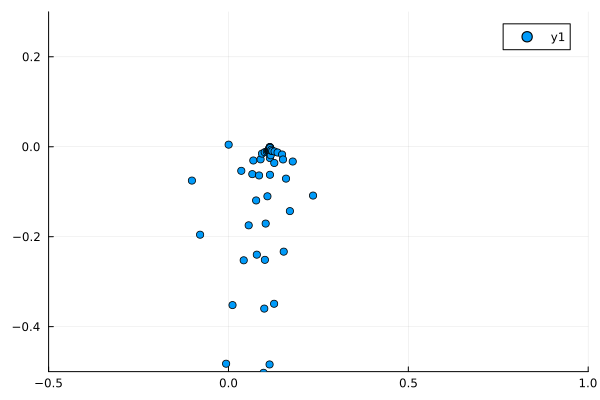

In [176]:
scatter(real(eigval),imag(eigval),xlims=[-0.5,1],ylims=[-0.5,0.3])